In [1]:
import pandas as pd
import shutil
from pathlib import Path

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
IMAGES_SUBDIR = "images"   # adjust to your actual structure
MASKS_SUBDIR = "masks"

redundant_df = pd.read_csv("redundant_images.csv")

# Normalize class names to match your folder names if needed
# e.g. "Viral Pneumonia" -> "Viral_Pneumonia" if your folders use underscores
class_folder_map = {
    "COVID": "COVID",
    "Normal": "Normal",
    "Lung_Opacity": "Lung_Opacity",
    "Viral Pneumonia": "Viral Pneumonia",
}

redundant_files = set(
    (row["class"], row["redundant_file"])
    for _, row in redundant_df.iterrows()
)
print(f"Total files to exclude: {len(redundant_files)}")

Total files to exclude: 59


In [2]:
def copy_class(class_name, folder_name):
    src_dir = RAW_DIR / folder_name
    dst_dir = PROCESSED_DIR / folder_name
    (dst_dir / "images").mkdir(parents=True, exist_ok=True)
    (dst_dir / "masks").mkdir(parents=True, exist_ok=True)

    copied, skipped = 0, 0
    for img_path in (src_dir / "images").glob("*.png"):
        if (class_name, img_path.name) in redundant_files:
            skipped += 1
            continue
        shutil.copy2(img_path, dst_dir / "images" / img_path.name)
        mask_path = src_dir / "masks" / img_path.name
        if mask_path.exists():
            shutil.copy2(mask_path, dst_dir / "masks" / img_path.name)
        copied += 1

    print(f"{class_name}: copied {copied}, skipped {skipped}")

for class_name, folder_name in class_folder_map.items():
    copy_class(class_name, folder_name)

COVID: copied 3565, skipped 51
Normal: copied 10191, skipped 1
Lung_Opacity: copied 6012, skipped 0
Viral Pneumonia: copied 1338, skipped 7


In [3]:
print(RAW_DIR.resolve())
print(RAW_DIR.exists())
print(list(RAW_DIR.iterdir()))

C:\Projects\jun26_bds_int_covid\data\raw
True
[WindowsPath('../data/raw/.gitkeep'), WindowsPath('../data/raw/COVID'), WindowsPath('../data/raw/COVID.metadata.xlsx'), WindowsPath('../data/raw/Lung_Opacity'), WindowsPath('../data/raw/Lung_Opacity.metadata.xlsx'), WindowsPath('../data/raw/Normal'), WindowsPath('../data/raw/Normal.metadata.xlsx'), WindowsPath('../data/raw/README.md'), WindowsPath('../data/raw/Viral Pneumonia'), WindowsPath('../data/raw/Viral Pneumonia.metadata.xlsx')]


In [4]:
total_images = sum(
    len(list((PROCESSED_DIR / folder / "images").glob("*.png")))
    for folder in class_folder_map.values()
)
total_masks = sum(
    len(list((PROCESSED_DIR / folder / "masks").glob("*.png")))
    for folder in class_folder_map.values()
)
print(f"Images: {total_images}, Masks: {total_masks}") 

Images: 21106, Masks: 21106


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

records = []
for class_name, folder_name in class_folder_map.items():
    img_dir = PROCESSED_DIR / folder_name / "images"
    for img_path in img_dir.glob("*.png"):
        records.append({
            "class": class_name,
            "image_path": str(img_path),
            "mask_path": str(PROCESSED_DIR / folder_name / "masks" / img_path.name),
        })

manifest = pd.DataFrame(records)

train_df, temp_df = train_test_split(manifest, test_size=0.3, stratify=manifest["class"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["class"], random_state=42)

print(train_df["class"].value_counts(normalize=True))
print(val_df["class"].value_counts(normalize=True))
print(test_df["class"].value_counts(normalize=True))  # proportions should match across all three

class
Normal             0.482875
Lung_Opacity       0.284825
COVID              0.168878
Viral Pneumonia    0.063422
Name: proportion, dtype: float64
class
Normal             0.482628
Lung_Opacity       0.284902
COVID              0.168983
Viral Pneumonia    0.063487
Name: proportion, dtype: float64
class
Normal             0.482944
Lung_Opacity       0.284902
COVID              0.168983
Viral Pneumonia    0.063171
Name: proportion, dtype: float64


In [6]:
import cv2
import numpy as np

def preprocess_xray(img_path, mask_path, target_size=(224, 224),
                     apply_lung_mask=False, apply_clahe_norm=False, augment=False):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    if mask is None:
        raise ValueError(f"Could not read mask: {mask_path}")

    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)

    if augment:
        img, mask = augment_pair(img, mask)

    if apply_clahe_norm:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img = clahe.apply(img)

    if apply_lung_mask:
        binary_mask = (mask > 127).astype('uint8')
        img = cv2.bitwise_and(img, img, mask=binary_mask)

    img = img.astype('float32')
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    return img

In [7]:
def build_array_dataset(df, target_size=(224, 224), apply_lung_mask=False,apply_clahe_norm=False):
    X, y = [], []
    failed = []
    for idx, row in df.iterrows():
        try:
            img = preprocess_xray(row["image_path"], row["mask_path"],
                                   target_size=target_size, apply_lung_mask=apply_lung_mask, apply_clahe_norm=False)
            X.append(img)
            y.append(row["class"])
        except Exception as e:
            failed.append((row["image_path"], str(e)))

    if failed:
        print(f"{len(failed)} files failed to process:")
        for path, err in failed[:10]:  # show first 10
            print(f"  {path}: {err}")

    return np.array(X), np.array(y)

In [8]:
X_train, y_train = build_array_dataset(train_df)
X_val, y_val = build_array_dataset(val_df)
X_test, y_test = build_array_dataset(test_df)

In [21]:
from pathlib import Path

SPLITS = ["train", "val", "test"]
fresh = {
    "train": (X_train, y_train),
    "val": (X_val, y_val),
    "test": (X_test, y_test),
}

processed_images = sum(
    len(list((PROCESSED_DIR / folder / "images").glob("*.png")))
    for folder in class_folder_map.values()
)
print(f"Processed folder images: {processed_images}")
print(f"Manifest images: {len(manifest)}")
print(f"Fresh total samples: {sum(x.shape[0] for x, _ in fresh.values())}")

if processed_images != len(manifest):
    print("WARNING: manifest count does not match processed folder count.")

all_match = True
for split in SPLITS:
    X_new, y_new = fresh[split]
    x_path = Path(f"X_{split}.npy")
    y_path = Path(f"y_{split}.npy")

    print(f"\n{split.upper()}")
    print(f"  Fresh: {X_new.shape[0]} samples")
    print(f"  Classes: {pd.Series(y_new).value_counts().to_dict()}")

    if not (x_path.exists() and y_path.exists()):
        print("  No previous save on disk.")
        all_match = False
        continue

    X_old, y_old = np.load(x_path), np.load(y_path)
    print(f"  Previous save: {X_old.shape[0]} samples")

    same_shape = X_old.shape == X_new.shape
    same_labels = np.array_equal(y_old, y_new)
    same_values = same_shape and np.allclose(X_old, X_new)

    print(f"  Same shape: {same_shape}")
    print(f"  Same labels: {same_labels}")
    print(f"  Same pixel values: {same_values}")

    if same_shape and not same_values:
        diff = np.abs(X_old - X_new)
        changed = np.any(diff.reshape(len(X_old), -1) > 0, axis=1)
        print(f"  Max pixel diff: {diff.max():.6e}")
        print(f"  Changed samples: {changed.sum()} / {len(X_old)}")
    elif not same_shape:
        print(f"  Sample count change: {X_old.shape[0]} -> {X_new.shape[0]} ({X_new.shape[0] - X_old.shape[0]:+d})")

    all_match &= same_shape and same_labels and same_values

if all_match:
    print("\nNo data lost — fresh build matches previous save exactly.")
else:
    print("\nDifferences detected — review counts and diffs above before saving.")

Processed folder images: 21106
Manifest images: 21106
Fresh total samples: 21106

TRAIN
  Fresh: 14774 samples
  Classes: {'Normal': 7134, 'Lung_Opacity': 4208, 'COVID': 2495, 'Viral Pneumonia': 937}
  Previous save: 14774 samples
  Same shape: True
  Same labels: True
  Same pixel values: True

VAL
  Fresh: 3166 samples
  Classes: {'Normal': 1528, 'Lung_Opacity': 902, 'COVID': 535, 'Viral Pneumonia': 201}
  Previous save: 3166 samples
  Same shape: True
  Same labels: True
  Same pixel values: True

TEST
  Fresh: 3166 samples
  Classes: {'Normal': 1529, 'Lung_Opacity': 902, 'COVID': 535, 'Viral Pneumonia': 200}
  Previous save: 3166 samples
  Same shape: True
  Same labels: True
  Same pixel values: True

No data lost — fresh build matches previous save exactly.


In [9]:
np.save("X_train.npy", X_train); np.save("y_train.npy", y_train)
np.save("X_val.npy", X_val); np.save("y_val.npy", y_val)
np.save("X_test.npy", X_test); np.save("y_test.npy", y_test)

In [10]:
import platform
print(platform.processor())
print(platform.machine()) 

AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD
AMD64


In [19]:
import cv2
import numpy as np
import random

def _random_flip(img, mask):
    if random.random() < 0.5:
        img = cv2.flip(img, 1)
        mask = cv2.flip(mask, 1)
    return img, mask


def _rotation_zoom_scale(w, h, angle_deg):
    angle_rad = np.deg2rad(abs(angle_deg))
    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)
    bb_w = w * cos_a + h * sin_a
    bb_h = w * sin_a + h * cos_a
    return max(bb_w / w, bb_h / h)

def _random_rotation_old(img, mask, max_angle=15):
    angle = random.uniform(-max_angle, max_angle)
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    mask = cv2.warpAffine(mask, M, (w, h), borderMode=cv2.BORDER_REFLECT,
                           flags=cv2.INTER_NEAREST)
    return img, mask

def _random_rotation_with_zoom(img, mask, max_angle=15, extra_zoom=0.02):
    angle = random.uniform(-max_angle, max_angle)
    h, w = img.shape[:2]
    scale = _rotation_zoom_scale(w, h, angle)
    scale *= 1 + random.uniform(0, extra_zoom)
    center = (w / 2, h / 2)
    M = cv2.getRotationMatrix2D(center, angle, scale)
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    mask = cv2.warpAffine(mask, M, (w, h), borderMode=cv2.BORDER_CONSTANT,
                           flags=cv2.INTER_NEAREST, borderValue=0)
    return img, mask

def _random_zoom(img, mask, zoom_range=0.08):
    h, w = img.shape[:2]
    zoom = 1 + random.uniform(-zoom_range, zoom_range)
    new_h, new_w = int(h * zoom), int(w * zoom)

    img_r = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    mask_r = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    if zoom > 1:  # crop back to original size
        top = (new_h - h) // 2
        left = (new_w - w) // 2
        img_r = img_r[top:top+h, left:left+w]
        mask_r = mask_r[top:top+h, left:left+w]
    else:  # pad back to original size
        pad_h, pad_w = h - new_h, w - new_w
        top, left = pad_h // 2, pad_w // 2
        img_r = cv2.copyMakeBorder(img_r, top, pad_h - top, left, pad_w - left,
                                    cv2.BORDER_REFLECT)
        mask_r = cv2.copyMakeBorder(mask_r, top, pad_h - top, left, pad_w - left,
                                     cv2.BORDER_CONSTANT, value=0)
    return img_r, mask_r

def _random_translation(img, mask, shift_range=0.05):
    h, w = img.shape[:2]
    tx = random.uniform(-shift_range, shift_range) * w
    ty = random.uniform(-shift_range, shift_range) * h
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    mask = cv2.warpAffine(mask, M, (w, h), borderMode=cv2.BORDER_REFLECT,
                           flags=cv2.INTER_NEAREST)
    return img, mask

def _random_brightness_contrast(img, brightness_range=0.1, contrast_range=0.1):
    # intensity-only op - mask untouched
    alpha = 1 + random.uniform(-contrast_range, contrast_range)
    beta = random.uniform(-brightness_range, brightness_range) * 255
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

def augment_pair(img, mask):
    if random.random() < 0.5:
        img, mask = _random_flip(img, mask)

    if random.random() < 0.5:
        img, mask = _random_rotation(img, mask)

    if random.random() < 0.5:
        img, mask = _random_zoom(img, mask)

    if random.random() < 0.5:
        img, mask = _random_translation(img, mask)

    if random.random() < 0.4:
        img = _random_brightness_contrast(img)

    return img, mask

Original: (299, 299, 3) (256, 256)
Flip: (299, 299, 3) (256, 256)
Rotation (old): (299, 299, 3) (299, 299)
Rotation (new): (299, 299, 3) (299, 299)
Zoom: (299, 299, 3) (299, 299)


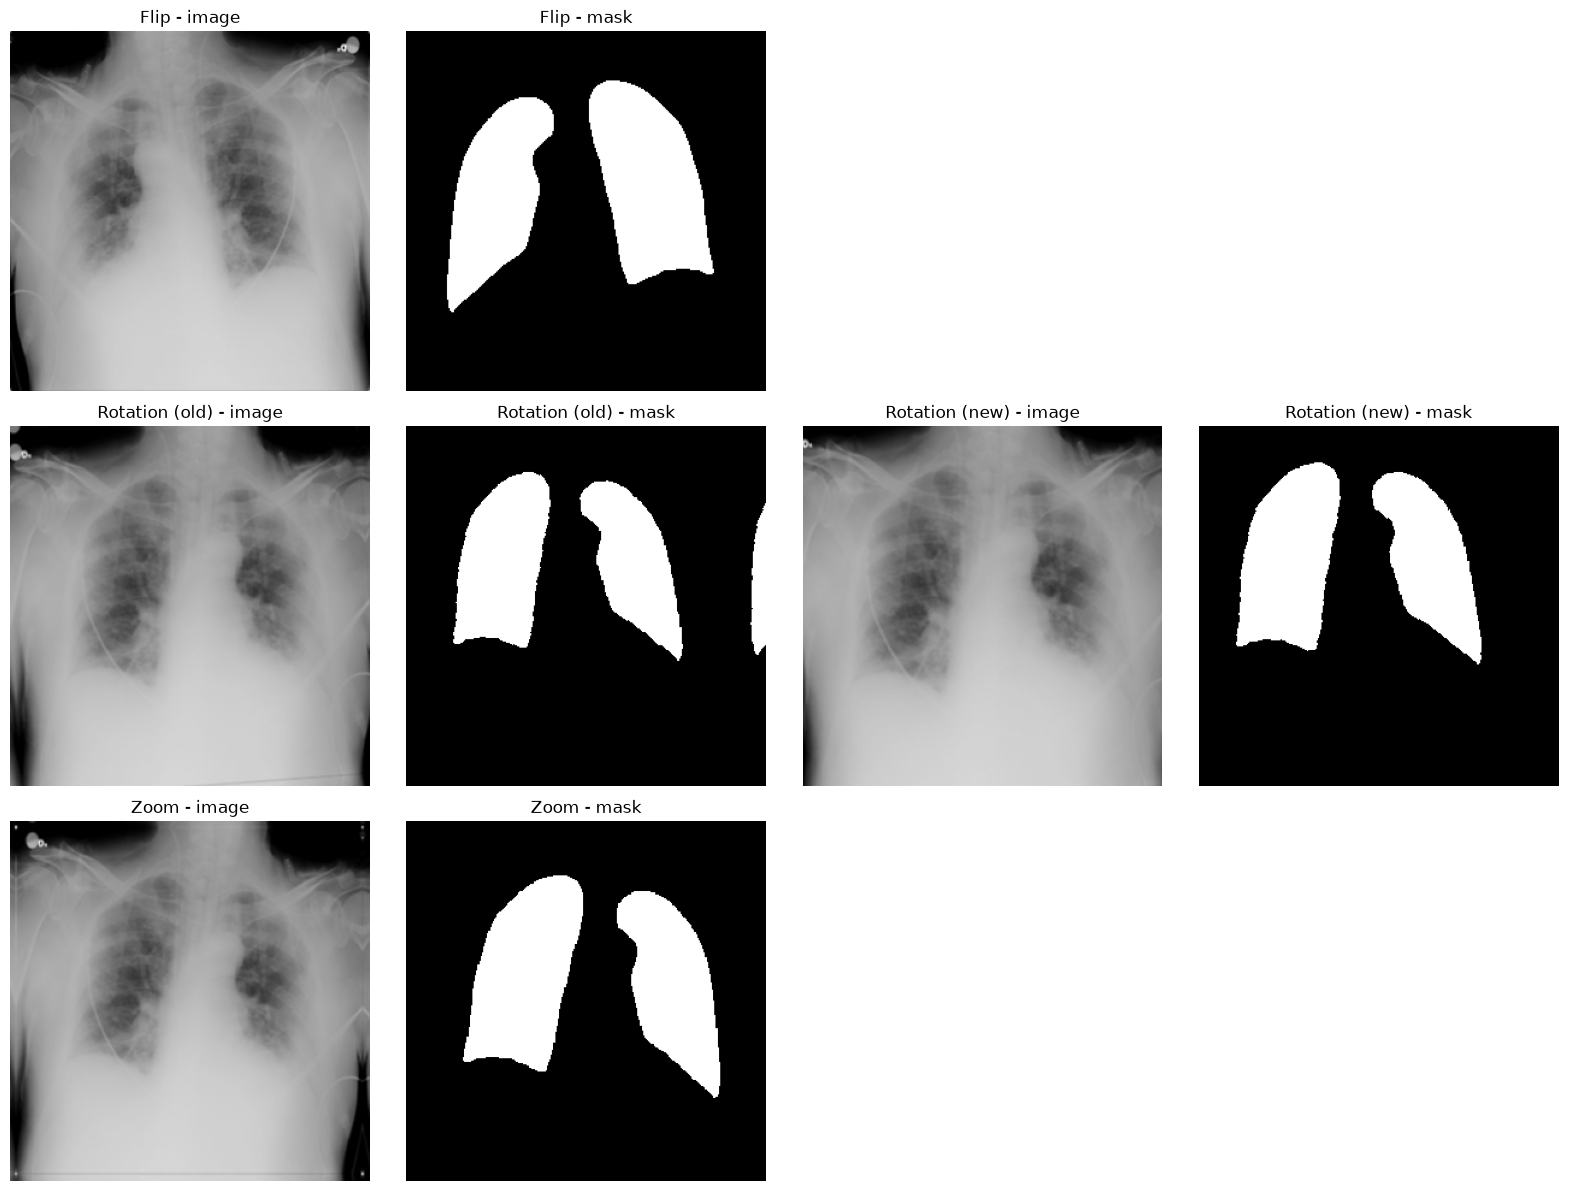

In [20]:
import matplotlib.pyplot as plt


img = cv2.imread("../data/processed/COVID/images/COVID-1.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mask = cv2.imread("../data/processed/COVID/masks/COVID-1.png", cv2.IMREAD_GRAYSCALE)

flip_img, flip_mask = _random_flip(img.copy(), mask.copy())

random.seed(42)
old_rot_img, old_rot_mask = _random_rotation_old(img.copy(), mask.copy())
random.seed(42)
new_rot_img, new_rot_mask = _random_rotation_with_zoom(img.copy(), mask.copy())

zoom_img, zoom_mask = _random_zoom(img.copy(), mask.copy())

print("Original:", img.shape, mask.shape)
print("Flip:", flip_img.shape, flip_mask.shape)
print("Rotation (old):", old_rot_img.shape, old_rot_mask.shape)
print("Rotation (new):", new_rot_img.shape, new_rot_mask.shape)
print("Zoom:", zoom_img.shape, zoom_mask.shape)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

axes[0, 0].imshow(flip_img)
axes[0, 0].set_title("Flip - image")
axes[0, 0].axis("off")
axes[0, 1].imshow(flip_mask, cmap="gray")
axes[0, 1].set_title("Flip - mask")
axes[0, 1].axis("off")
for col in (2, 3):
    axes[0, col].axis("off")

axes[1, 0].imshow(old_rot_img)
axes[1, 0].set_title("Rotation (old) - image")
axes[1, 0].axis("off")
axes[1, 1].imshow(old_rot_mask, cmap="gray")
axes[1, 1].set_title("Rotation (old) - mask")
axes[1, 1].axis("off")
axes[1, 2].imshow(new_rot_img)
axes[1, 2].set_title("Rotation (new) - image")
axes[1, 2].axis("off")
axes[1, 3].imshow(new_rot_mask, cmap="gray")
axes[1, 3].set_title("Rotation (new) - mask")
axes[1, 3].axis("off")

axes[2, 0].imshow(zoom_img)
axes[2, 0].set_title("Zoom - image")
axes[2, 0].axis("off")
axes[2, 1].imshow(zoom_mask, cmap="gray")
axes[2, 1].set_title("Zoom - mask")
axes[2, 1].axis("off")
for col in (2, 3):
    axes[2, col].axis("off")

plt.tight_layout()
plt.show()

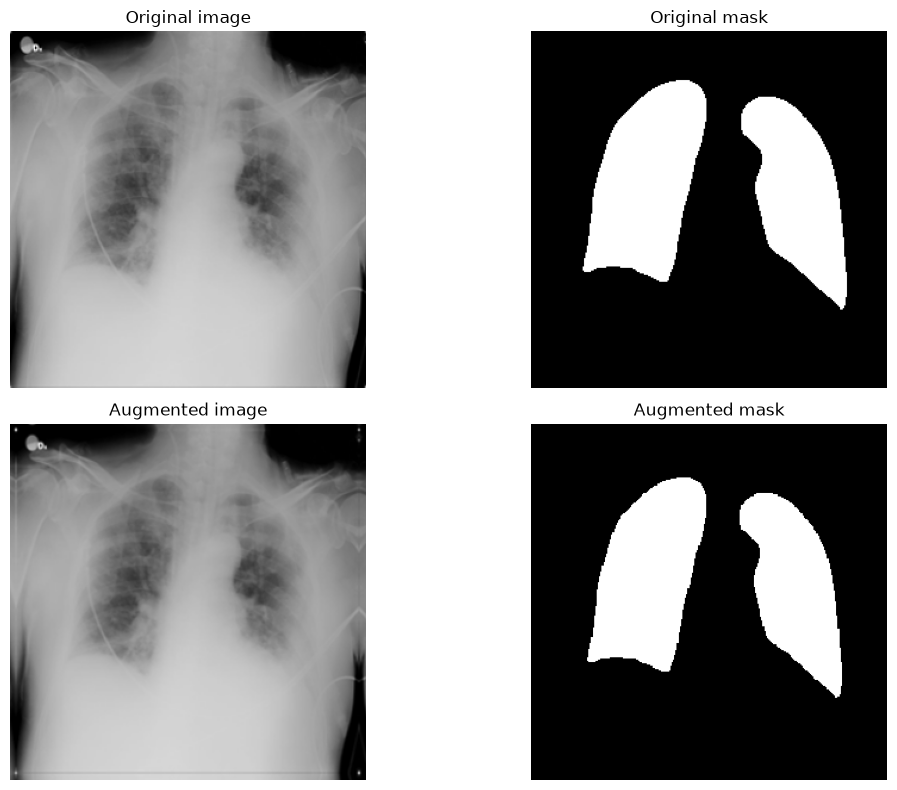

In [13]:
import matplotlib.pyplot as plt

img = cv2.imread("../data/processed/COVID/images/COVID-1.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread("../data/processed/COVID/masks/COVID-1.png", cv2.IMREAD_GRAYSCALE)

aug_img, aug_mask = augment_pair(img.copy(), mask.copy())

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title("Original image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Original mask")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(aug_img)
plt.title("Augmented image")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(aug_mask, cmap="gray")
plt.title("Augmented mask")
plt.axis("off")

plt.tight_layout()
plt.show()